<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/PCA/PCA_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PCA Scratch

In [1]:
import numpy as np

class PCAScratch:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        # 1. Mean centering
        self.mean = np.mean(X, axis=0)
        X = X - self.mean

        # 2. Covariance matrix
        # row = samples, col = features
        cov = np.cov(X.T)

        # 3. Eigenvalues, Eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(cov)

        # 4. Sort eigenvectors by eigenvalues in descending order
        eigenvectors = eigenvectors.T
        idxs = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]

        # 5. Store first n components
        self.components = eigenvectors[0:self.n_components]

    def transform(self, X):
        # Project data onto principal components
        X = X - self.mean
        return np.dot(X, self.components.T)

PCA Class

In [2]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# 1. Load & Scale
iris = load_iris()
X, y = iris.data, iris.target

# 2. Fit and Transform
pca = PCAScratch(n_components=2)
pca.fit(X)
X_projected = pca.transform(X)

print(f"Original shape: {X.shape}")
print(f"Transformed shape: {X_projected.shape}")

Original shape: (150, 4)
Transformed shape: (150, 2)


Execution

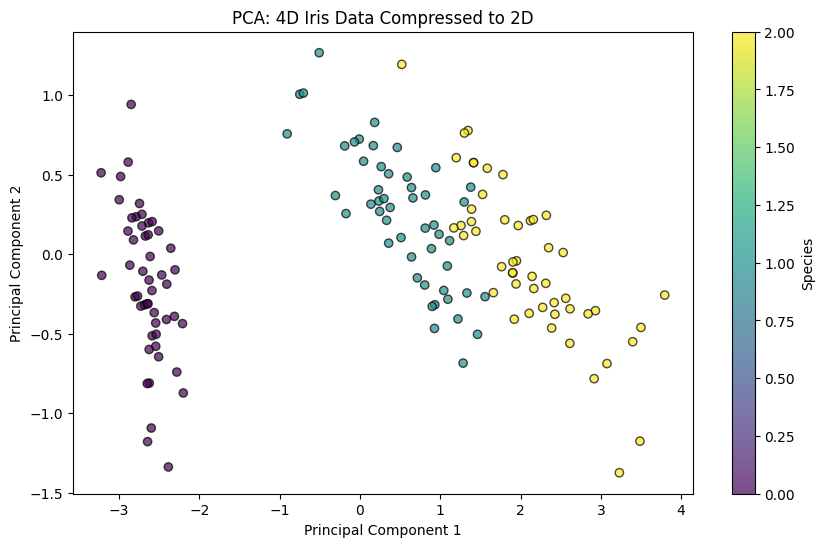

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X_projected[:, 0], X_projected[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: 4D Iris Data Compressed to 2D')
plt.colorbar(label='Species')
plt.show()

2D Visualization

In [4]:
import plotly.graph_objects as go

# Calculate explained variance
cov = np.cov(X.T)
evals, _ = np.linalg.eig(cov)
exp_var = evals / np.sum(evals)

fig = go.Figure(data=[go.Bar(x=['PC1', 'PC2', 'PC3', 'PC4'], y=exp_var)])
fig.update_layout(title="Scree Plot: Information Captured per Component",
                  yaxis_title="Variance Ratio")
fig.show()

3D Visualization

moved from "grouping" data (K-Means) to simplifying it. We used linear algebra—specifically the covariance matrix and eigendecomposition—to find the "true" axes of the data. The first principal component (PC1) captures the most significant variation, while each subsequent component captures the remaining variance in decreasing order. In your Edge AI and robotics projects, PCA is vital: it reduces the computational load on your flight controller by filtering out redundant sensor noise and focusing only on the signals that actually change the state of the machine.